In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, box

In [4]:
Distribution_Data = pd.read_csv('ev_distribution_dataset.csv')
Geospatial_Data = pd.read_csv('geospatial_dataset.csv')
weather_data = pd.read_csv('weather_dataset.csv')

In [5]:
#Extract lat and long from ev Charging Stations
Distribution_Data['ev_latitude'] = Distribution_Data['EV_Charging_Station_Location'].apply(
    lambda x: float(x.split(",")[0].replace("(", "").strip()))
Distribution_Data['ev_longitude'] = Distribution_Data['EV_Charging_Station_Location'].apply(
    lambda x: float(x.split(",")[1].replace(")", "").strip()))                                                                  
                                                                                                                                       
#Extract lat and long for substation location                                                                                                                                
Geospatial_Data['substation_latitude'] = Geospatial_Data['Substation_Location'].apply(
    lambda x: float(x.split(",")[0].replace("(", "").strip()))
Geospatial_Data['substation_longitude'] = Geospatial_Data['Substation_Location'].apply(
    lambda x: float(x.split(",")[1].replace(")", "").strip()))

#Drop the original Location columns to clean up the dataframe
Distribution_Data = Distribution_Data.drop(columns=['EV_Charging_Station_Location'])
Geospatial_Data = Geospatial_Data.drop(columns=['Substation_Location'])
                                                                         

/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


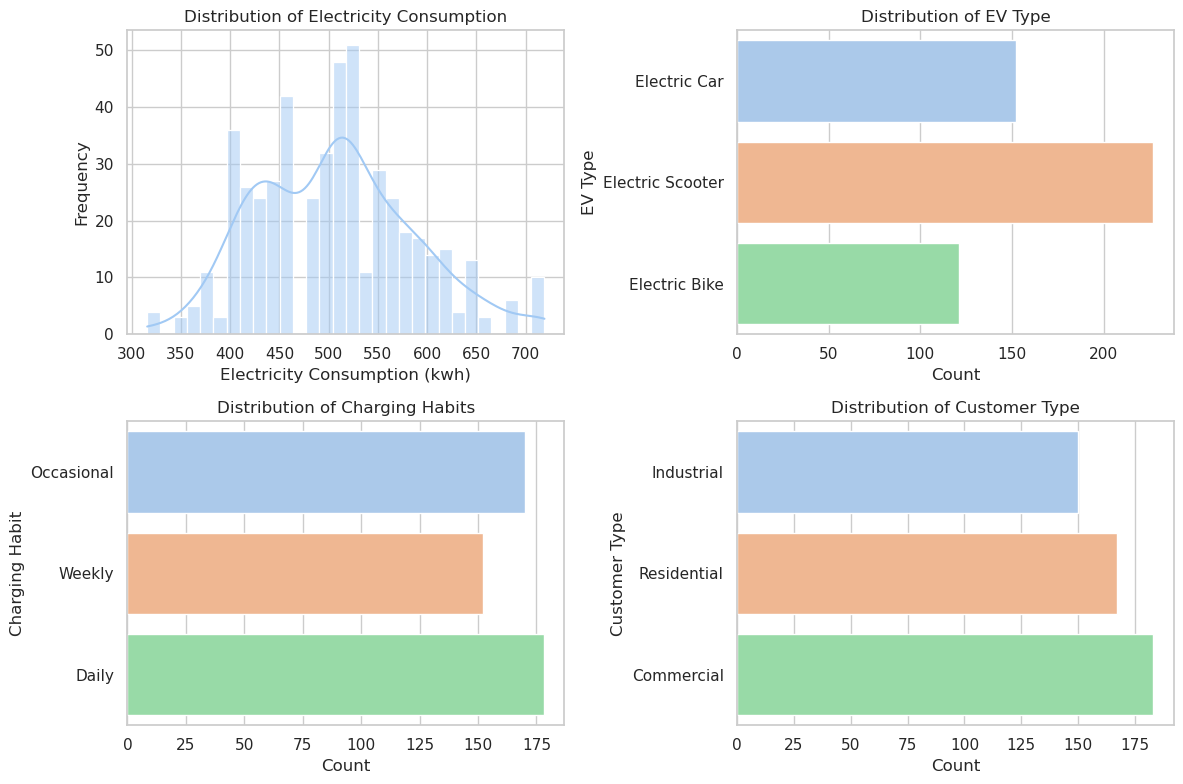

In [6]:
# Set the style and color of the plots

sns.set(style="whitegrid")
sns.set_palette("pastel")

# Create a 2x2 subplot grid
fig, axes =plt.subplots(2, 2, figsize=(12, 8))

# Plot the distribution of electricity consumption
sns.histplot(data= Distribution_Data, x="Electricity_Consumption (kWh)", bins=30, kde=True, ax=axes [0, 0],) 
axes[0, 0].set_title("Distribution of Electricity Consumption")
axes[0, 0].set_xlabel("Electricity Consumption (kwh)")
axes[0, 0].set_ylabel("Frequency")

# Plot the distribution of EV types
sns.countplot(data=Distribution_Data, y="EV_Type", ax=axes[0, 1])
axes[0, 1].set_title("Distribution of EV Type")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_ylabel("EV Type")

# Plot the distribution of Charging Habits
sns.countplot(data=Distribution_Data, y="Charging_Habit", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Charging Habits")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("Charging Habit")

# Plot the distribution of Customer type
sns.countplot(data=Distribution_Data, y="Customer_Type", ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Customer Type")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("Customer Type")

# Adjust Layout
plt.tight_layout()

# Show the plots
plt.show()

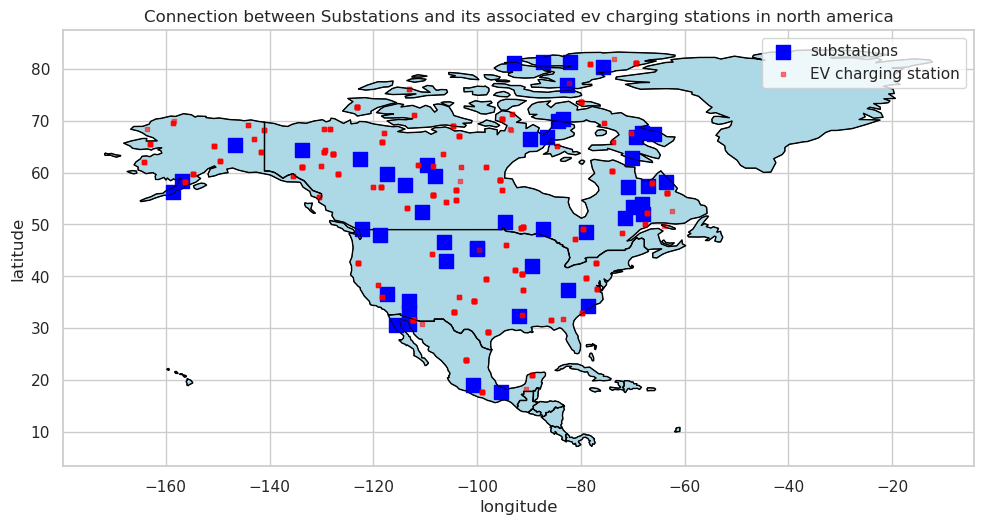

In [10]:
# Convert the dataframes to Geodataframes
ev_gdf = gpd.GeoDataFrame(Distribution_Data,
                          geometry=gpd.points_from_xy(Distribution_Data.ev_longitude, Distribution_Data.ev_latitude))
substation_gdf = gpd.GeoDataFrame(Geospatial_Data,
                                  geometry=gpd.points_from_xy(Geospatial_Data.substation_longitude, Geospatial_Data.substation_latitude))


#Create lines connecting each substation to it's associated ev charging
#lines= []
#for _, ev_row in Distribution_Data.iterrows():
    #substation = Geospatial_Data[Geospatial_Data['Substation_ID'] == ev_row['Substation_ID']].iloc[0]
   # line=[(ev_row['ev_longitude'], ev_row['ev_latitude']),
    #       (substation['substation_longitude'], substation['substation_latitude'])]
    #lines.append(line)

#line_gdf = gpd.GeoDataFrame(geometry=[LineString(line) for line in lines])


#Load the world map data

world = gpd.read_file('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson')


#filter the map to North America
north_america = world[world['CONTINENT']== "North America"]

#plotting the map for north america
fig, ax = plt.subplots(figsize= (10, 6))
north_america.boundary.plot(ax=ax, linewidth= 0.5, color= 'black')
north_america.plot(ax=ax, color= 'lightblue', edgecolor= 'black')

#plotting the substation on the map
substation_gdf.plot(ax=ax, marker= 's', markersize = 100, color = 'blue', label= 'substations')
#plotting ev charging stations on the map
ev_gdf.plot(ax=ax, marker= 's', markersize = 10, color = 'red', label= 'EV charging station', alpha = 0.5)

#plotting line
#line_gdf.plot(ax=ax, linewidth= 0.5, color= 'grey', label= 'connections')

#set title and axis labels
plt.title('Connection between Substations and its associated ev charging stations in north america')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.legend()
plt.tight_layout()
plt.show()





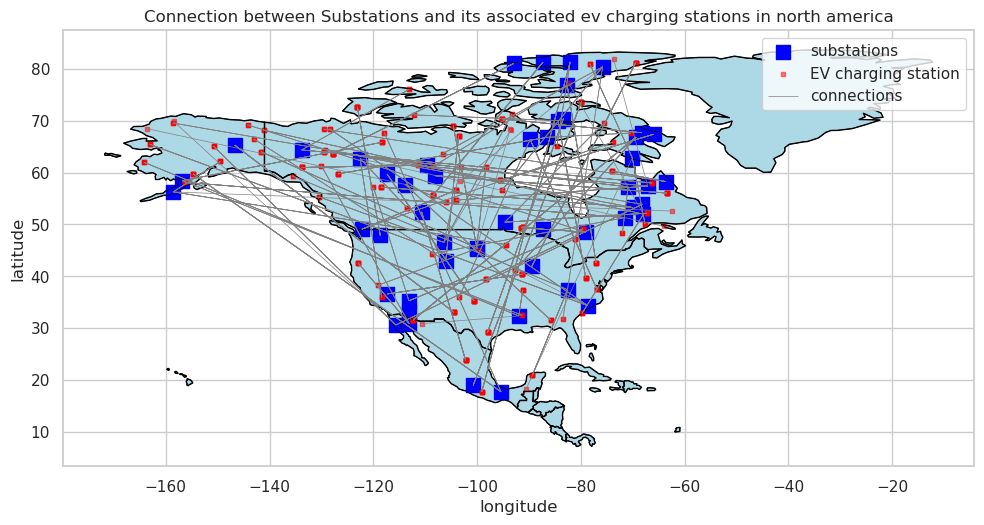

In [12]:
# Convert the dataframes to Geodataframes
ev_gdf = gpd.GeoDataFrame(Distribution_Data,
                          geometry=gpd.points_from_xy(Distribution_Data.ev_longitude, Distribution_Data.ev_latitude))
substation_gdf = gpd.GeoDataFrame(Geospatial_Data,
                                  geometry=gpd.points_from_xy(Geospatial_Data.substation_longitude, Geospatial_Data.substation_latitude))


#Create lines connecting each substation to it's associated ev charging
lines= []
for _, ev_row in Distribution_Data.iterrows():
    substation = Geospatial_Data[Geospatial_Data['Substation_ID'] == ev_row['Substation_ID']].iloc[0]
    line=[(ev_row['ev_longitude'], ev_row['ev_latitude']),
           (substation['substation_longitude'], substation['substation_latitude'])]
    lines.append(line)

line_gdf = gpd.GeoDataFrame(geometry=[LineString(line) for line in lines])


#Load the world map data

world = gpd.read_file('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson')


#filter the map to North America
north_america = world[world['CONTINENT']== "North America"]

#plotting the map for north america
fig, ax = plt.subplots(figsize= (10, 6))
north_america.boundary.plot(ax=ax, linewidth= 0.5, color= 'black')
north_america.plot(ax=ax, color= 'lightblue', edgecolor= 'black')

#plotting the substation on the map
substation_gdf.plot(ax=ax, marker= 's', markersize = 100, color = 'blue', label= 'substations')
#plotting ev charging stations on the map
ev_gdf.plot(ax=ax, marker= 's', markersize = 10, color = 'red', label= 'EV charging station', alpha = 0.5)

#plotting line
line_gdf.plot(ax=ax, linewidth= 0.5, color= 'grey', label= 'connections')

#set title and axis labels
plt.title('Connection between Substations and its associated ev charging stations in north america')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.legend()
plt.tight_layout()
plt.show()





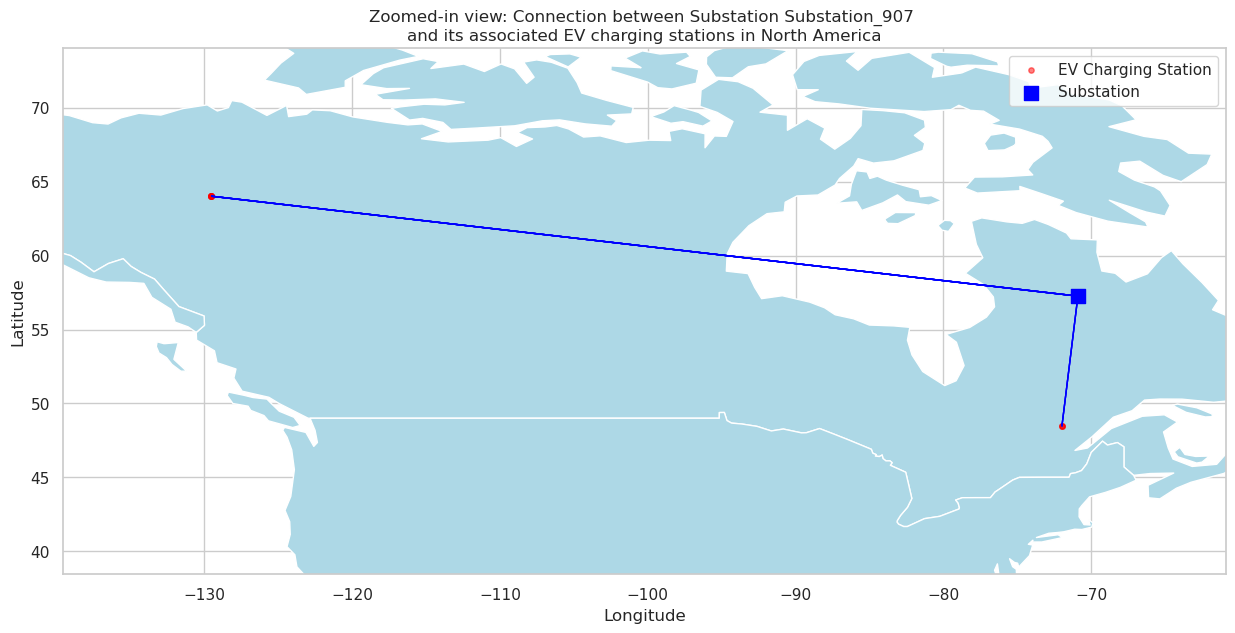

In [14]:
# Filter for the first substation
selected_substation = Geospatial_Data.iloc[0]

# Get associated EV charging stations
associated_ev = Distribution_Data[Distribution_Data['Substation_ID'] == selected_substation['Substation_ID']]

# Create GeoDataFrame for EV stations
ev_gdf_selected = gpd.GeoDataFrame(
    associated_ev, 
    geometry=gpd.points_from_xy(
        associated_ev['ev_longitude'],
        associated_ev['ev_latitude']
    )
)

# Create lines between substation and EV charging stations
lines_selected = [
    LineString([
        (ev_row['ev_longitude'], ev_row['ev_latitude']),
        (selected_substation['substation_longitude'], selected_substation['substation_latitude'])
    ]) 
    for _, ev_row in associated_ev.iterrows()
]

# Create GeoDataFrame for lines
line_gdf_selected = gpd.GeoDataFrame(geometry=lines_selected)

# Load the world map data
#world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")


# Filter for North America
north_america = world[world['CONTINENT'] == "North America"]

# Create buffer around the lines (in degrees)
buffer_distance = 10

# Get the bounds of the line geometry with buffer
minx, miny, maxx, maxy = line_gdf_selected.total_bounds
xlim = [minx - buffer_distance, maxx + buffer_distance]
ylim = [miny - buffer_distance, maxy + buffer_distance]

# Create the plot
fig, ax = plt.subplots(figsize=(15, 10))

# Plot base map
north_america.plot(ax=ax, color='lightblue')

# Plot lines
line_gdf_selected.plot(ax=ax, color='blue', linewidth=1)

# Plot EV stations
ev_gdf_selected.plot(
    ax=ax,
    marker='o',
    markersize=15,
    color='red',
    label='EV Charging Station',
    alpha=0.5
)


# Plot substation (single point)
ax.scatter(
    selected_substation['substation_longitude'],
    selected_substation['substation_latitude'],
    marker='s',
    s=100,  # size parameter for scatter
    color='blue',
    label='Substation',
    zorder=5  # ensure it's plotted on top
)

# Set map bounds
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Set title and axis labels
ax.set_title(f'Zoomed-in view: Connection between Substation {selected_substation["Substation_ID"]} \nand its associated EV charging stations in North America')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add legend
ax.legend()

plt.show()


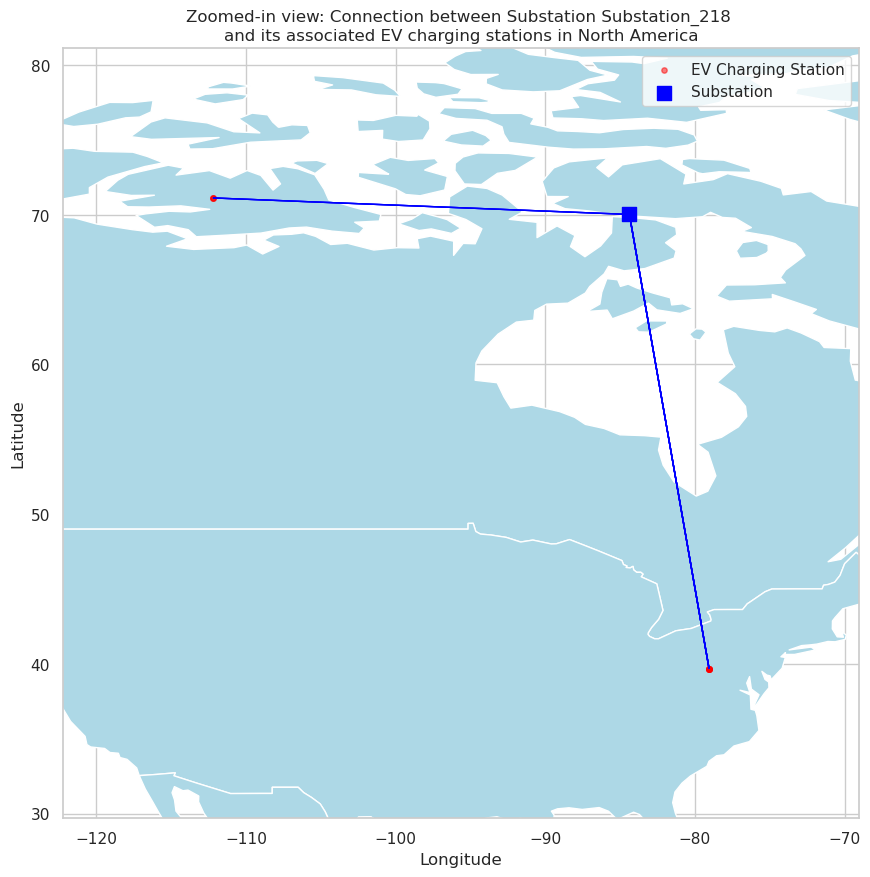

In [18]:
# Filter for the first substation
selected_substation = Geospatial_Data.iloc[1]

# Get associated EV charging stations
associated_ev = Distribution_Data[Distribution_Data['Substation_ID'] == selected_substation['Substation_ID']]

# Create GeoDataFrame for EV stations
ev_gdf_selected = gpd.GeoDataFrame(
    associated_ev, 
    geometry=gpd.points_from_xy(
        associated_ev['ev_longitude'],
        associated_ev['ev_latitude']
    )
)

# Create lines between substation and EV charging stations
lines_selected = [
    LineString([
        (ev_row['ev_longitude'], ev_row['ev_latitude']),
        (selected_substation['substation_longitude'], selected_substation['substation_latitude'])
    ]) 
    for _, ev_row in associated_ev.iterrows()
]

# Create GeoDataFrame for lines
line_gdf_selected = gpd.GeoDataFrame(geometry=lines_selected)

# Load the world map data
#world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")


# Filter for North America
north_america = world[world['CONTINENT'] == "North America"]

# Create buffer around the lines (in degrees)
buffer_distance = 10

# Get the bounds of the line geometry with buffer
minx, miny, maxx, maxy = line_gdf_selected.total_bounds
xlim = [minx - buffer_distance, maxx + buffer_distance]
ylim = [miny - buffer_distance, maxy + buffer_distance]

# Create the plot
fig, ax = plt.subplots(figsize=(15, 10))

# Plot base map
north_america.plot(ax=ax, color='lightblue')

# Plot lines
line_gdf_selected.plot(ax=ax, color='blue', linewidth=1)

# Plot EV stations
ev_gdf_selected.plot(
    ax=ax,
    marker='o',
    markersize=15,
    color='red',
    label='EV Charging Station',
    alpha=0.5
)


# Plot substation (single point)
ax.scatter(
    selected_substation['substation_longitude'],
    selected_substation['substation_latitude'],
    marker='s',
    s=100,  # size parameter for scatter
    color='blue',
    label='Substation',
    zorder=5  # ensure it's plotted on top
)

# Set map bounds
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Set title and axis labels
ax.set_title(f'Zoomed-in view: Connection between Substation {selected_substation["Substation_ID"]} \nand its associated EV charging stations in North America')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add legend
ax.legend()

plt.show()


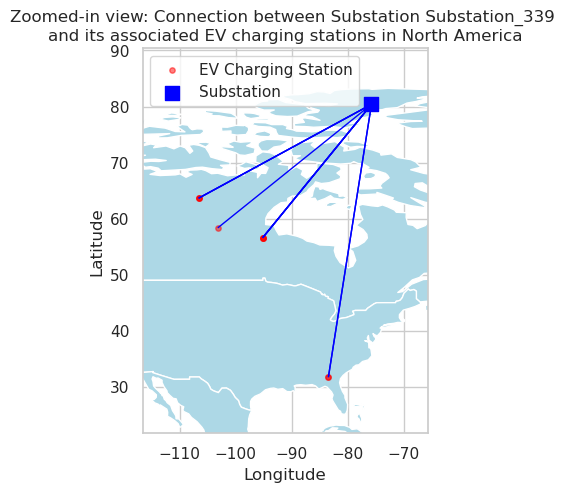

In [19]:
# Filter for the first substation
selected_substation = Geospatial_Data.iloc[2]

# Get associated EV charging stations
associated_ev = Distribution_Data[Distribution_Data['Substation_ID'] == selected_substation['Substation_ID']]

# Create GeoDataFrame for EV stations
ev_gdf_selected = gpd.GeoDataFrame(
    associated_ev, 
    geometry=gpd.points_from_xy(
        associated_ev['ev_longitude'],
        associated_ev['ev_latitude']
    )
)

# Create lines between substation and EV charging stations
lines_selected = [
    LineString([
        (ev_row['ev_longitude'], ev_row['ev_latitude']),
        (selected_substation['substation_longitude'], selected_substation['substation_latitude'])
    ]) 
    for _, ev_row in associated_ev.iterrows()
]

# Create GeoDataFrame for lines
line_gdf_selected = gpd.GeoDataFrame(geometry=lines_selected)

# Load the world map data
#world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")


# Filter for North America
north_america = world[world['CONTINENT'] == "North America"]

# Create buffer around the lines (in degrees)
buffer_distance = 10

# Get the bounds of the line geometry with buffer
minx, miny, maxx, maxy = line_gdf_selected.total_bounds
xlim = [minx - buffer_distance, maxx + buffer_distance]
ylim = [miny - buffer_distance, maxy + buffer_distance]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot base map
north_america.plot(ax=ax, color='lightblue')

# Plot lines
line_gdf_selected.plot(ax=ax, color='blue', linewidth=1)

# Plot EV stations
ev_gdf_selected.plot(
    ax=ax,
    marker='o',
    markersize=15,
    color='red',
    label='EV Charging Station',
    alpha=0.5
)


# Plot substation (single point)
ax.scatter(
    selected_substation['substation_longitude'],
    selected_substation['substation_latitude'],
    marker='s',
    s=100,  # size parameter for scatter
    color='blue',
    label='Substation',
    zorder=5  # ensure it's plotted on top
)

# Set map bounds
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Set title and axis labels
ax.set_title(f'Zoomed-in view: Connection between Substation {selected_substation["Substation_ID"]} \nand its associated EV charging stations in North America')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add legend
ax.legend()

plt.show()


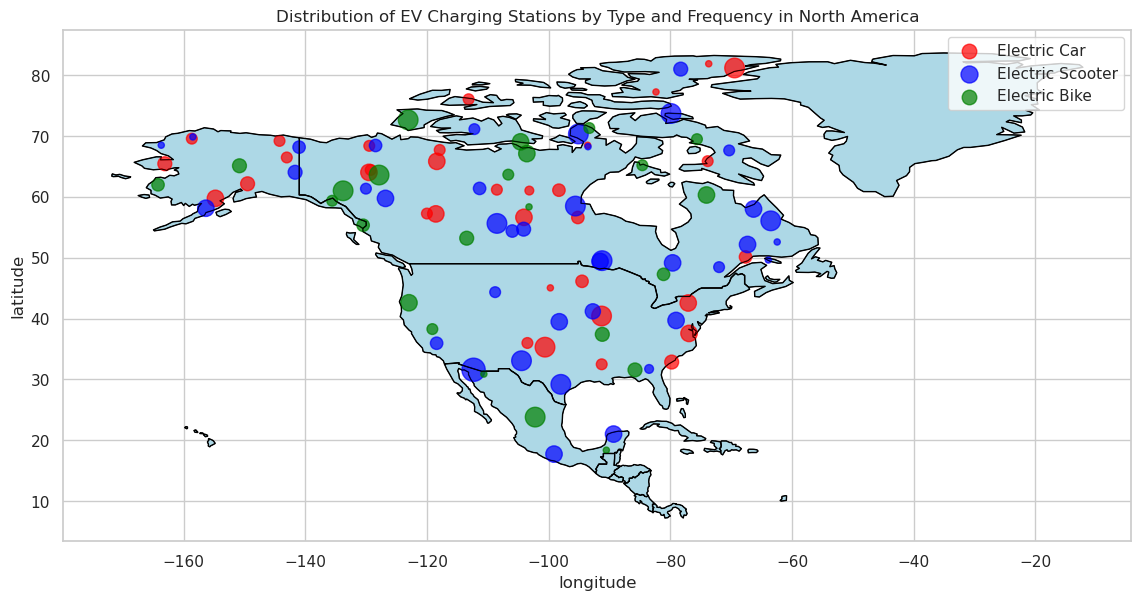

In [22]:

#groupby Location and the ev type, then count the number of stations
grouped_data = Distribution_Data.groupby(['ev_latitude', 'ev_longitude', 'EV_Type']).size().reset_index(name='count')

#convert grouped data to GeoDataFrame
grouped_gdf = gpd.GeoDataFrame(grouped_data,
                             geometry=gpd.points_from_xy(grouped_data.ev_longitude, grouped_data.ev_latitude))

#Load the world map data and filter for North America
world = gpd.read_file('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson')


#filter the map to North America
north_america = world[world['CONTINENT']== "North America"]

fig, ax = plt.subplots(figsize =(12, 6))
north_america.boundary.plot(
    ax=ax,
    linewidth=0.5,
    color='black'
)

north_america.plot(
    ax=ax,
    color='lightblue',
    edgecolor= 'black'
)

#Define the colors of ev type
colors = {'Electric Car': 'red', 'Electric Scooter': 'blue', 'Electric Bike': 'green'}
          
#plot the EV charging stations with marker sizes reflecting the count
for ev_type, color in colors.items():
    sub_gdf = grouped_gdf[grouped_gdf['EV_Type'] == ev_type]
    sub_gdf.plot(ax=ax, markersize=sub_gdf['count']*20, color=color, label=ev_type, alpha=0.7)

plt.title('Distribution of EV Charging Stations by Type and Frequency in North America')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
#Group the ev distribution data by substation id and calculate the total electricity consumption for each substation
total_consumption_per_substation = Distribution_Data.groupby('Substation_ID')['Electricity_Consumption (kWh)'].sum().reset_index()

#merging the total_consumption data with geospatial data
network_capacity_data = pd.merge(Geospatial_Data, total_consumption_per_substation, on= 'Substation_ID')

#Renaming columns for better understanding
#network_capacity.rename(columns = {'Electricity_Consumption (kwh)': 'Total_Consumption (kwh)' inplace= True})
network_capacity_data.rename(columns={'Electricity_Consumption (kWh)': 'Total_Consumption (kWh)'}, inplace=True)

#Calculating the ratio of total consumption to transmission line Capacity
# Conversion: 1MW = 1000 kWh
network_capacity_data['Consumption_to_Capacity_Ratio']= network_capacity_data['Total_Consumption (kWh)'] /(network_capacity_data['Transmission_Line_Capacity (MW)'] * 1000)
                                                              






In [26]:
from shapely.geometry import Point

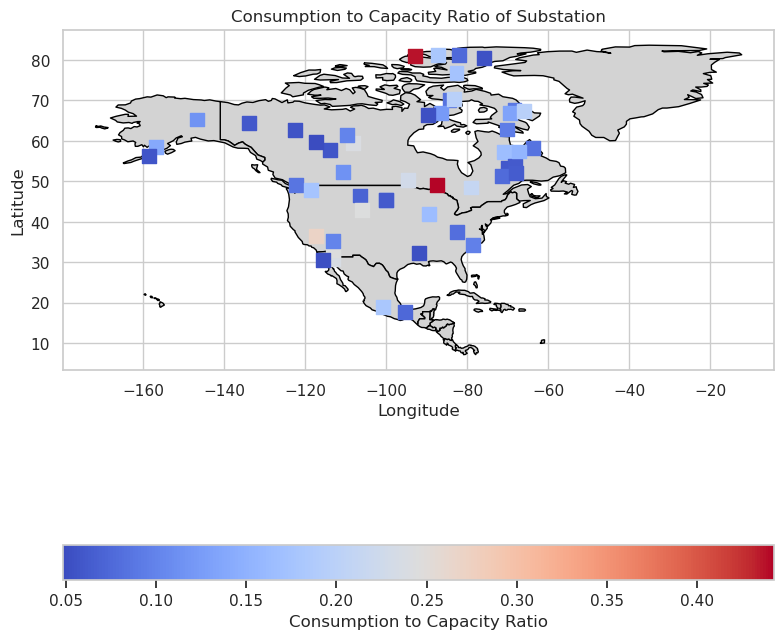

In [28]:
# Create geometry points from longitude and latitude
geometry_network_capacity = [Point(lon, lat) for lon, lat in zip (network_capacity_data['substation_longitude'], network_capacity_data['substation_latitude'])]
gdf_network_capacity = gpd.GeoDataFrame(network_capacity_data, geometry=geometry_network_capacity)

#plotting
fig, ax = plt.subplots(figsize= (8, 12))
north_america.plot(ax=ax, color= 'lightgray', edgecolor = 'black')
gdf_network_capacity.plot(column= 'Consumption_to_Capacity_Ratio', cmap= 'coolwarm', legend = True, marker= 's', markersize= 100, ax =ax, legend_kwds={'label': 'Consumption to Capacity Ratio', 'orientation': 'horizontal'})

ax.set_title('Consumption to Capacity Ratio of Substation')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

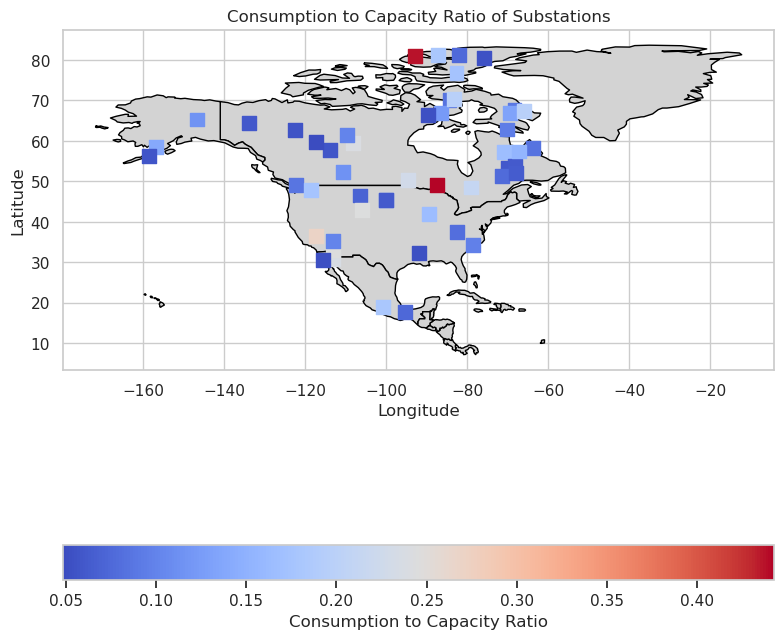

In [30]:

# Create geometry points from longitude and latitude
geometry_network_capacity = [Point(lon, lat) for lon, lat in zip(network_capacity_data['substation_longitude'], 
                                                                network_capacity_data['substation_latitude'])]

# Create GeoDataFrame
gdf_network_capacity = gpd.GeoDataFrame(network_capacity_data, geometry=geometry_network_capacity)

# Create plot
fig, ax = plt.subplots(figsize=(8, 12))  # Fixed syntax error: subplot -> subplots

# Plot base map and data
north_america.plot(ax=ax, color='lightgray', edgecolor='black')  # Fixed syntax error: ax+ax -> ax=ax
gdf_network_capacity.plot(column='Consumption_to_Capacity_Ratio',
                         cmap='coolwarm',
                         legend=True,
                         marker='s',
                         markersize=100,
                         ax=ax,
                         legend_kwds={'label': 'Consumption to Capacity Ratio',
                                    'orientation': 'horizontal'})

# Set title and labels
ax.set_title('Consumption to Capacity Ratio of Substations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [32]:
#Group by the substation_id for the number of evs
ev_counts= Distribution_Data.groupby('Substation_ID')['Number_of_EVs'].sum().reset_index()

#merge network capacity data with ev counts
final_data= pd.merge(ev_counts, network_capacity_data, on= 'Substation_ID')

#Correlation
correlation_ratio= final_data['Number_of_EVs'].corr(final_data['Consumption_to_Capacity_Ratio'])

In [34]:
correlation_ratio

-0.10944923035990646

<function matplotlib.pyplot.show(close=None, block=None)>

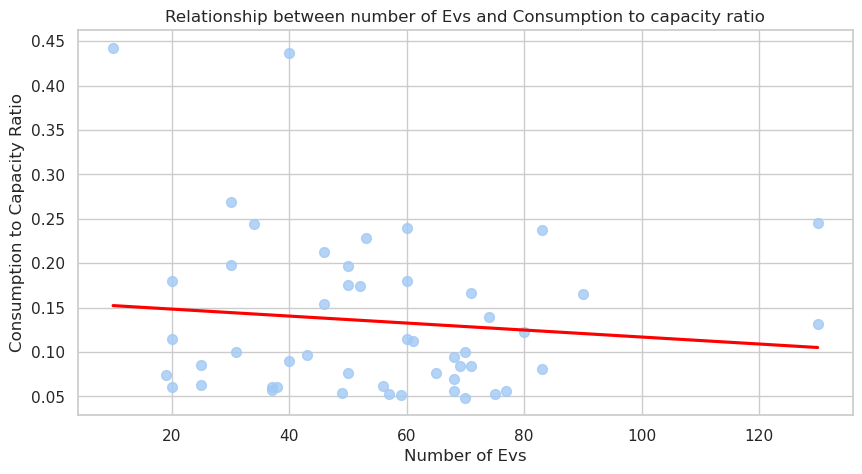

In [36]:
plt.figure(figsize =(10, 5))
sns.regplot(x='Number_of_EVs', y= 'Consumption_to_Capacity_Ratio', data= final_data, scatter_kws={'s':50}, line_kws={'color':'red'}, ci= None)
plt.title('Relationship between number of Evs and Consumption to capacity ratio')
plt.xlabel('Number of Evs')
plt.ylabel('Consumption to Capacity Ratio')
plt.grid(True)
plt.tight_layout
plt.show

In [38]:
top_5_substations = network_capacity_data.nlargest(5, 'Consumption_to_Capacity_Ratio')
top_5_substations

,Substation_ID,Transmission_Line_Capacity (MW),substation_latitude,substation_longitude,Total_Consumption (kWh),Consumption_to_Capacity_Ratio
3,Substation_773,10,49.123078,-87.359890,4426.337993,0.442634
14,Substation_87,12,81.031814,-92.941747,5243.800714,0.436983
27,Substation_711,17,36.618181,-117.277556,4579.354677,0.269374
20,Substation_11,43,33.082269,-113.118931,10534.827701,0.244996
42,Substation_258,22,42.952789,-106.049333,5378.214378,0.244464


In [40]:
network_capacity_data.rename(columns={'Consumption_Capacity_Ratio': 'Consumption_to_Capacity_Ratio'}, inplace=True)

In [48]:
#merge weather data with distribution data
merged_data = pd.merge(Distribution_Data, weather_data, on= ['Timestamp', 'Substation_ID'])

#Calculate the correlation brtween weather condition and electricity consumption
correlation_matrix = merged_data[['Electricity_Consumption (kWh)', 'Temperature (°C)', 'Precipitation (mm)']].corr()

#display
correlation_matrix

,Electricity_Consumption (kWh),Temperature (°C),Precipitation (mm)
Electricity_Consumption (kWh),1.000000,0.131543,0.085014
Temperature (°C),0.131543,1.000000,-0.005828
Precipitation (mm),0.085014,-0.005828,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

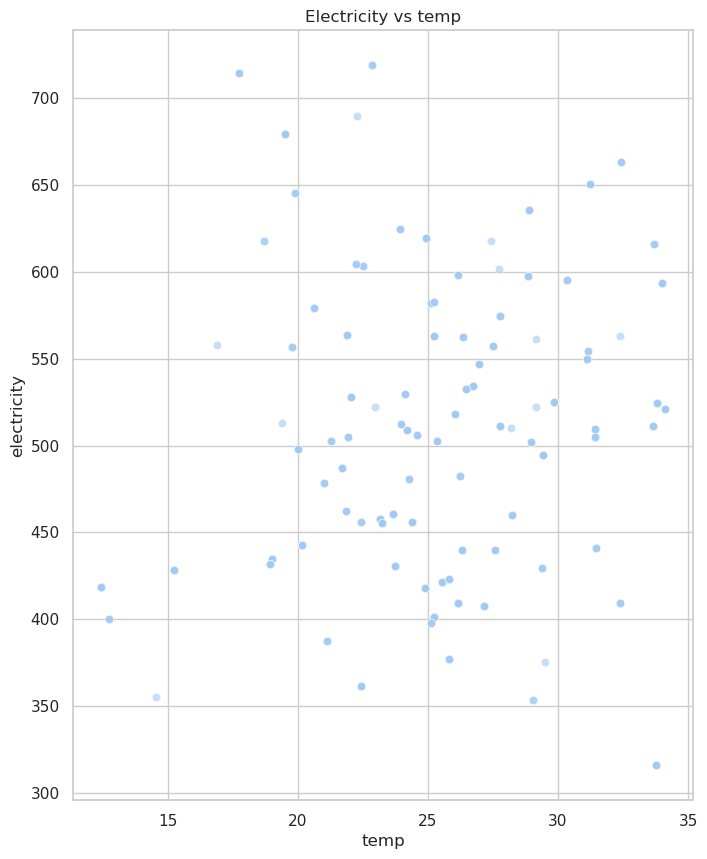

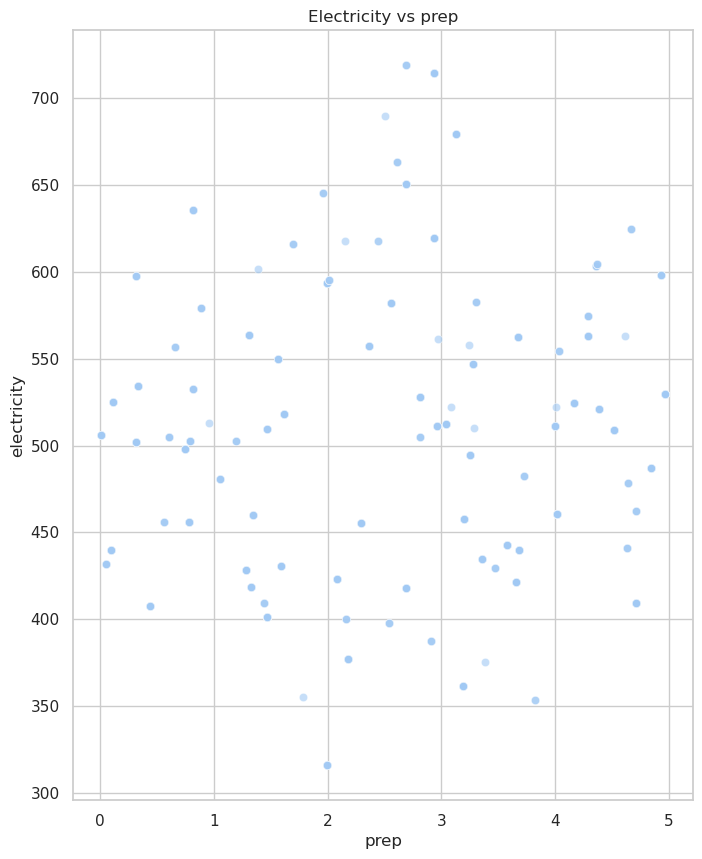

In [62]:
#Electricity consumption vs temp
plt. figure(figsize= (8, 10))
sns.scatterplot(data= merged_data, x='Temperature (°C)', y= 'Electricity_Consumption (kWh)', alpha= 0.6)
plt.title('Electricity vs temp')
plt.xlabel('temp')
plt.ylabel('electricity')
plt.show

#Electricity vs Precipitation
plt. figure(figsize= (8, 10))
sns.scatterplot(data= merged_data, x='Precipitation (mm)', y= 'Electricity_Consumption (kWh)', alpha= 0.6)
plt.title('Electricity vs prep')
plt.xlabel('prep')
plt.ylabel('electricity')
plt.show

In [ ]:
#Insights

#1. Electricity Consumption: The elctricity consumption is mostly centred around 500kwh with certain instances of higher consumption. 
#   This indicates varied demand at different times and locations.

#2. EV Types and Charging Habits: Electric scooters is the most common types of EVs. 
#   Most customers charge their EVs daily indicating a consisitent daily load on the distribution network

#3. Consumer Type: Most Customers are commercial consumers.

#4. Geospatial Distribution: The spatial distribution of substations and EV charging stations is widespread

#5. Geospatial Distribution: The EV charging station seems to be far from it's corresponding Substation.

#6. Network Capacity: Some substations have a high Consumption_to_Capacity_Ratio. indicating potential bottlenecks and overloads in the network. 
#   There is also no correlation with the number of EV's per substation and the Consumption to Capacity Ratio, this shows that Number of EV's is not a factor for overload.

#7. Weather Correlation: The correlation between weather conditions(temperature and precipitation)and electricity consumption is weak in the current dataset. 
#   Suggesting that other factors might be more influential in affecting consumption



# The Optimiation Strategy/Recommendation

# This is based on the analysis done and business problems at hand, all these should be incorporated into the business.

# 1. Prioritise Substation Upgrades: Prioritize upgrades at substations where the Consumption_to_Capacity_Ratio is high, indicating potential overloads. 
#    Upgrade the transmission lines because the EV Charging Stations are too far from their corresponding Substations

# 2. Geospatial Analysis for Upgrade Planning: Use geospatial analysis to optimal locations for new substations or upgrades to existing ones. 
#    Consider factors like the proximity to high load demand areas(areas with high consumption to capacity ration) and geographical constraints 

#3. Demand Side Management: Implement demand-side manangement strategies to balance the load on the grid. 
#    Encourage customers to charge their EV's during off-peak hours through incentives or dynamic pricing.

#4. Advanced Monitoring and Analytics: Deploy advanced monitoring systems to continuously monitor the health and performance of the distribution network. 
#   Use analytics to predict potential issues and take preventive action.
    
#5. Cost-Benefit Analysis: Conduct a comprehensive cost-benefit for different upgrade options. 
#  Consider factors like the cost of upgrades, operational costs, potential revenue from increased capacity and the impact on service reliability and customer satisfaction

#6. Customer Engagement: Engage with customers to understand their needs and expectations. 
#   Provide clear communication about network upgrades and how they will enhance service reliability and meet the growing demand for  EV charging.

#7. Continuous improvement: Continuously monitor and asses the performance of the distribution network. 
#   Gather feedback from customers and other stakeholders and use this feedback to make further improvements and optimizations.


# By following these steps, PowerCharge Utilies can develop an effective optimization strategy to manage the increased load from EV charging stations ensure the reliability 
# and reliance of the distribution network and meet the expectations of customers all while optimizing costs and ensuring regulatory compliance
